In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from allensdk.brain_observatory.behavior.behavior_project_cache.\
    behavior_neuropixels_project_cache \
    import VisualBehaviorNeuropixelsProjectCache

%matplotlib inline

Loading the Data

In [2]:
# Update this to a valid directory in your filesystem. This is where the data will be stored.
cache_dir = '../data/'

cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=cache_dir) #from_s3_cache(cache_dir=cache_dir)

c:\Users\matth\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\allensdk\api\cloud_cache\cloud_cache.py:547: OutdatedManifestWarning: You are loading visual-behavior-neuropixels_project_manifest_v0.5.0.json. A more up to date version of the dataset -- visual-behavior-ophys_project_manifest_v1.1.0.json -- exists online. To see the changes between the two versions of the dataset, run
VisualBehaviorNeuropixelsProjectCache.compare_manifests('visual-behavior-neuropixels_project_manifest_v0.5.0.json', 'visual-behavior-ophys_project_manifest_v1.1.0.json')
To load another version of the dataset, run
VisualBehaviorNeuropixelsProjectCache.load_manifest('visual-behavior-ophys_project_manifest_v1.1.0.json')
  warnings.warn(msg, OutdatedManifestWarning)


In [3]:
# get the metadata tables
units_table = cache.get_unit_table()

channels_table = cache.get_channel_table()

probes_table = cache.get_probe_table()

behavior_sessions_table = cache.get_behavior_session_table()

ecephys_sessions_table = cache.get_ecephys_session_table()

Choose A Session

In [4]:
session_id = 1064644573
session = cache.get_ecephys_session(
            ecephys_session_id=session_id)

c:\Users\matth\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:772: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


In [5]:
# Get Neural Data
units = session.get_units()
channels = session.get_channels()

unit_channels = units.merge(channels, left_on='peak_channel_id', right_index=True)

#first let's sort our units by depth
unit_channels = unit_channels.sort_values('probe_vertical_position', ascending=False)

#now we'll filter them
good_unit_filter = ((unit_channels['snr']>1)&
                    (unit_channels['isi_violations']<1)&
                    (unit_channels['firing_rate']>0.1))

good_units = unit_channels.loc[good_unit_filter]

spike_times = session.spike_times

# Stimulus Data
stimulus_presentations = session.stimulus_presentations
change_times = stimulus_presentations[stimulus_presentations['active']&
                            stimulus_presentations['is_change']]['start_time'].values

# Behavioral Data
eye_tracking = session.eye_tracking
running_speed = session.running_speed
licks = session.licks

In [57]:
min_t = session.trials.start_time.min()
max_t = session.trials.stop_time.max()

In [59]:
binSize = 1.0 # Can change this to any number of seconds
bins = np.arange(min_t, max_t+binSize, binSize)
len(bins)

3603

In [231]:
# Get running speed
binned_running_speed = []
for bin_start in bins[:-1]:
    bin_stop = bin_start + binSize
    start_idx = np.searchsorted(running_speed.timestamps, bin_start)
    stop_idx = np.searchsorted(running_speed.timestamps, bin_stop)

    bin_values = running_speed.speed.values[start_idx:stop_idx]
    mean_value = np.mean(bin_values[~np.isnan(bin_values)])
    binned_running_speed.append(mean_value)
binned_running_speed = np.array(binned_running_speed)

# Get pupil area
binned_pupil_area = []
for bin_start in bins[:-1]:
    bin_stop = bin_start + binSize
    start_idx = np.searchsorted(eye_tracking.timestamps, bin_start)
    stop_idx = np.searchsorted(eye_tracking.timestamps, bin_stop)

    if stop_idx - start_idx < 10:
        print("A")

    bin_values = eye_tracking.pupil_area.values[start_idx:stop_idx]
    mean_value = np.mean(bin_values[~np.isnan(bin_values)])
    binned_pupil_area.append(mean_value)
binned_pupil_area = np.array(binned_pupil_area)

# Get Units in Brain region of interest
area_of_interest = 'VISp'
binned_spike_counts = []
area_units = good_units[good_units['structure_acronym']==area_of_interest]
for iu, unit in area_units.iterrows():
    unit_spike_times = spike_times[iu]
    counts = np.histogram(spike_times[iu], bins)[0]
    binned_spike_counts.append(counts)
binned_spike_counts = np.array(binned_spike_counts)


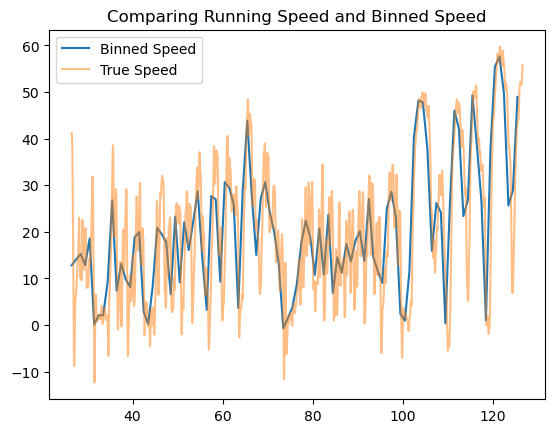

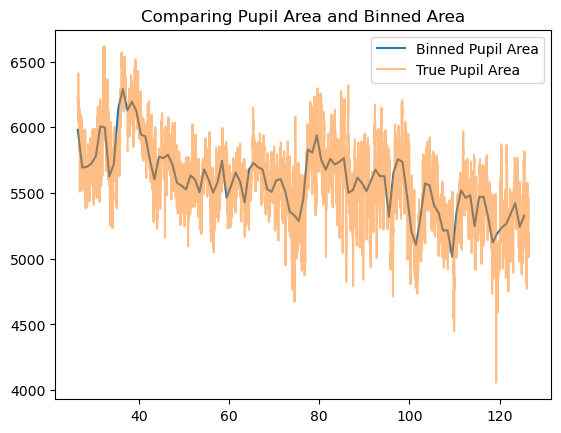

In [213]:
# Plot running speeds
plt.plot(bins[:100],binned_running_speed[:100], label="Binned Speed")

sdx = np.searchsorted(running_speed.timestamps.values, bins[0])
plt.plot(running_speed.timestamps.values[sdx:sdx+6000], running_speed.speed.values[sdx:sdx+6000], alpha=0.5, label="True Speed")

plt.legend()
plt.title("Comparing Running Speed and Binned Speed")
plt.show()


# Plot pupil areas
plt.plot(bins[:100],binned_pupil_area[:100], label="Binned Pupil Area")

sdx = np.searchsorted(eye_tracking.timestamps.values, bins[0])
plt.plot(eye_tracking.timestamps.values[sdx:sdx+6000], eye_tracking.pupil_area.values[sdx:sdx+6000], alpha=0.5, label="True Pupil Area")

plt.legend()
plt.title("Comparing Pupil Area and Binned Area")
plt.show()

Examples of Fitting

In [304]:
# For fitting, we should normalize the data

from sklearn.preprocessing import StandardScaler

norm_spike_counts = StandardScaler().fit_transform(binned_spike_counts.T).T
norm_running_speed = StandardScaler().fit_transform(binned_running_speed.reshape(-1,1)).T
norm_pupil_area = StandardScaler().fit_transform(binned_pupil_area.reshape(-1,1)).T


Can units in one brain region predict themselves?

In [240]:
from sklearn.linear_model import LinearRegression

# Set the target unit
is_tgt = np.zeros(norm_spike_counts.shape[0], dtype=bool)
is_tgt[10] = True

# Create inputs X and target Y

X = norm_spike_counts[~is_tgt].T
Y = norm_spike_counts[is_tgt].T
reg = LinearRegression().fit(X, Y)
y_hat = reg.predict(X)
reg.score(X, Y)

0.5692809408989925

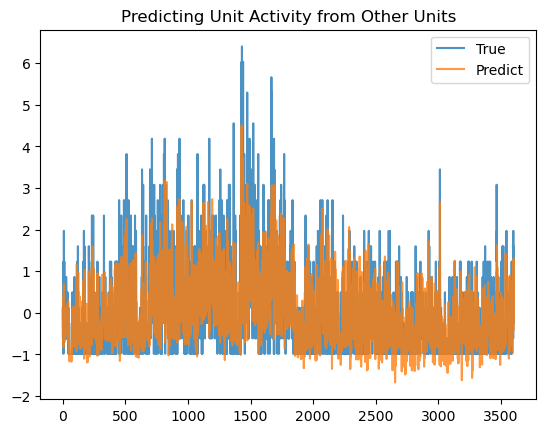

In [247]:
plt.plot(Y, alpha=0.8, label="True")
plt.plot(y_hat, alpha=0.8, label="Predict")
plt.legend()
plt.title("Predicting Unit Activity from Other Units")
plt.show()

In [43]:
# I couldn't get this to run quickly, but maybe you can

# from sklearn.kernel_ridge import KernelRidge
# import numpy as np
# rng = np.random.RandomState(0)
# krr = KernelRidge(alpha=1.0)
# krr.fit(X, y)
# y_hat_krr = reg.predict(X)
# krr.score(X, y)

Are there clusters of unit activity?

In [290]:
from sklearn.cluster import KMeans

n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(norm_spike_counts)

grs = []
for i in range(n_clusters):
    group_response = norm_spike_counts[kmeans.labels_==i, :]
    grs.append(group_response)

c:\Users\matth\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


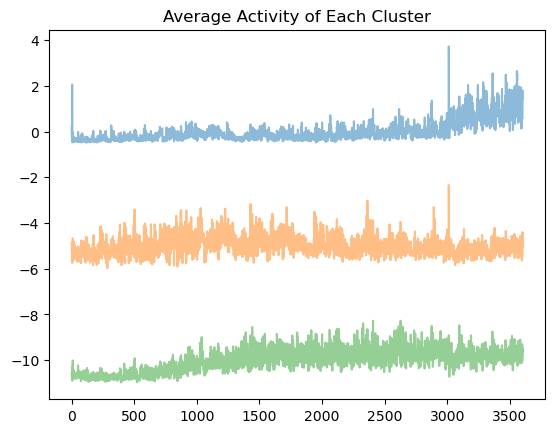

In [288]:
for i,gr in enumerate(grs):
    plt.plot(np.mean(gr,axis=0) - 5*i, alpha=0.5)

plt.title("Average Activity of Each Cluster")
plt.show()

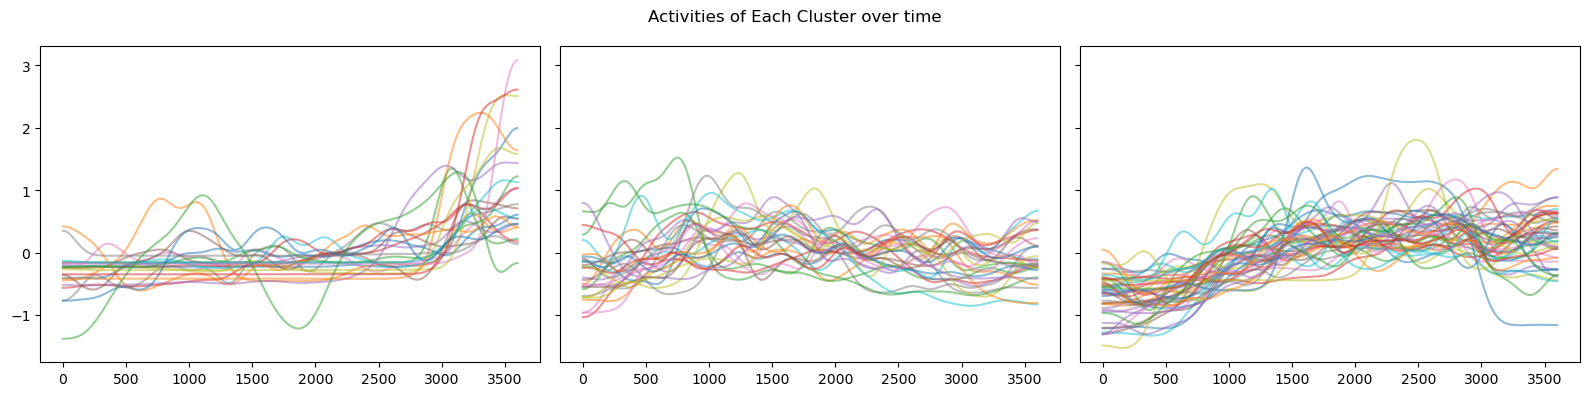

In [287]:
from scipy.ndimage import gaussian_filter1d as gf1d

fig, ax = plt.subplots(1, 3, figsize=(16,4), sharey=True)
for i,gr in enumerate(grs):
    ax[i].plot(gf1d(gr, sigma=100).T, alpha=0.5)
plt.suptitle("Activities of Each Cluster over time")
plt.tight_layout()
plt.show()

Do certain units correspond to known behaviors?

In [311]:
X.shape, Y.shape

((3602, 98), (3602, 1))

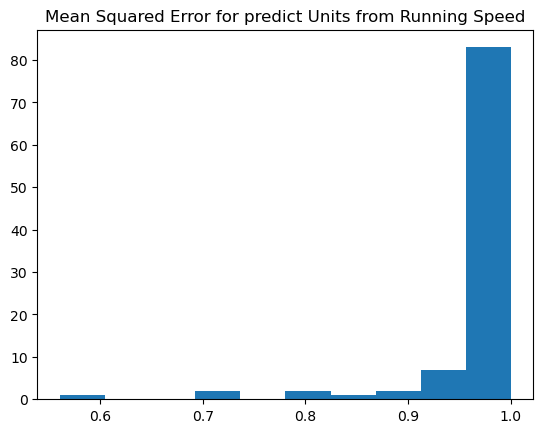

In [323]:
from sklearn.linear_model import LinearRegression

# Create inputs X and target Y
X = norm_spike_counts.T
Y = norm_running_speed.T

# Fit
reg = LinearRegression().fit(Y, X)
y_hat = reg.predict(Y)

# Look at errors
mse = np.mean((y_hat - X)**2, axis=0)
plt.hist(mse)
plt.title("Mean Squared Error for predict Units from Running Speed")
plt.show()

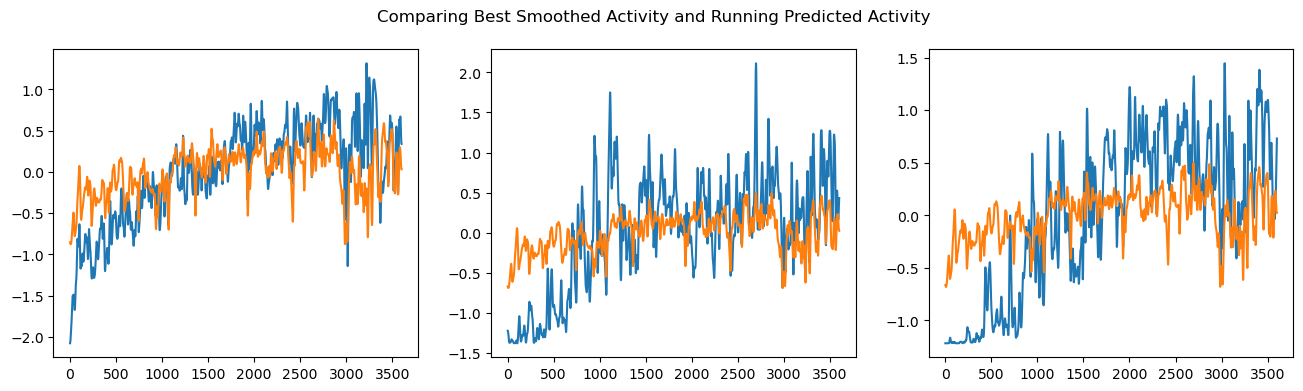

In [355]:
ordered_indices = np.argsort(mse)

fig, ax = plt.subplots(1, 3, figsize=(16,4))

for i,idx in enumerate(ordered_indices[:3]):
    ax[i].plot(gf1d(norm_spike_counts[idx], 5), label="True Spike Counts")
    ax[i].plot(gf1d(y_hat[:,idx], 5), label="Predicted Spike Counts")
plt.suptitle("Comparing Best Smoothed Activity and Running Predicted Activity")
plt.show()